In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec
from importlib import reload

In [7]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import summary

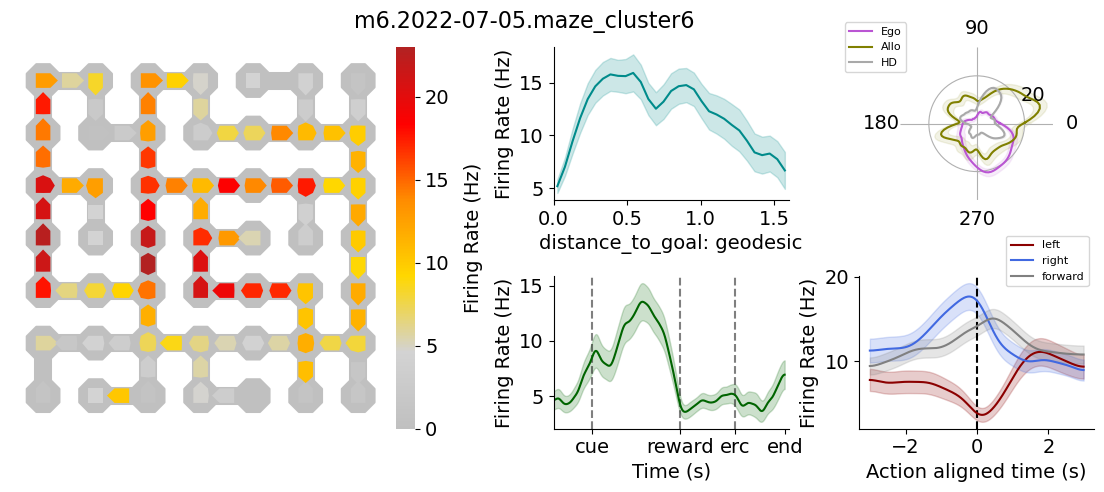

In [12]:
reload(summary)
Cluster = gc.get_cluster("m6.2022-07-05.maze_cluster6")
fig = summary.plot_tuning_summary_concise(Cluster)
fig.savefig("../results/nbeGLM/figures/cluster_tuning_summary.pdf")

In [3]:
from GridMaze.analysis.nbeGLM import load_model_sets as lms
from GridMaze.analysis.nbeGLM import model_comparisons as mc

# model performance validation

baseline vs embedding:
                                       feature_group model_type     t_stat  \
0                                    place_direction  baseline2  10.240604   
1                                    place_direction   baseline   8.893374   
2                   place_direction_distance_to_goal  baseline2  10.238096   
3                   place_direction_distance_to_goal   baseline  11.069190   
4  place_direction_distance_to_goal_egocentric_ac...  baseline2  12.143647   
5  place_direction_distance_to_goal_egocentric_ac...   baseline  11.648550   
6                                              place   baseline   5.212869   

      p_val  p_val_corr  
0  0.000153    0.000214  
1  0.000299    0.000349  
2  0.000153    0.000214  
3  0.000105    0.000214  
4  0.000067    0.000214  
5  0.000082    0.000214  
6  0.003430    0.003430  


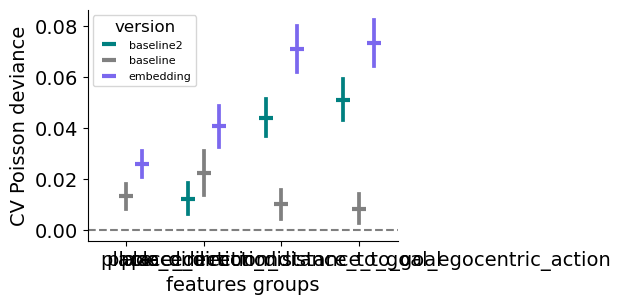

In [ ]:
nbe_validation = lms.load_model_set_cv_scores(
    model_set="performance_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=False
)
f, ax = plt.subplots(figsize=(4, 3))
mc.plot_performance_validation(nbe_validation, ax=ax)
f.savefig("../results/nbeGLM/figures/performance_validation.pdf")

# feature-group interactions validation

In [27]:
interaction_validation_results = lms.load_model_set_cv_scores(
    "interaction_validation", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=False
)

(-0.025, 0.1)

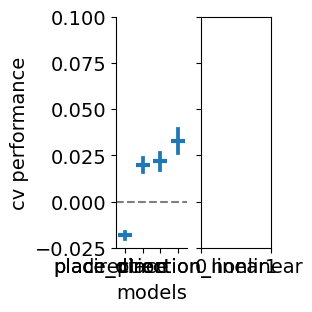

In [ ]:
reload(mc)
f, axes = plt.subplots(1, 2, figsize=(2, 3), sharey=True)
mc.plot_interaction_validation(
    interaction_validation_results,
    models=["place", "direction", "place_direction_linear", "place_direction_nonlinear"],
    ax=axes[0],
)
axes[0].set_ylim(-0.025, 0.1)

# unique variance explained

In [6]:
from GridMaze.analysis.nbeGLM import variance_explained as ve

In [ ]:
variance_explained_results = lms.load_model_set_cv_scores(
    "variance_explained", maze_names=["maze_1", "maze_2", "rooms_maze"], all_completed=True
)
cpd_df = ve.get_cpd_df(variance_explained_results)
feature_tuned_df = ve.get_feature_tuned_df(variance_explained_results)
compare_features = ["distance_to_goal", "place_direction", "egocentric_action_action"]

                    feature    t_stat     p_val  p_val_corr
0          distance_to_goal  4.418985  0.003449    0.005174
1  egocentric_action_action  3.978180  0.005275    0.005275
2           place_direction  5.340448  0.001544    0.004632


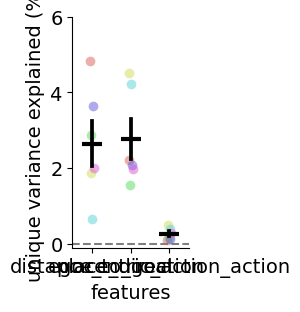

In [36]:
reload(ve)
f, ax = plt.subplots(figsize=(1.5, 3))
ve.plot_variance_explained(cpd_df, features=compare_features, print_stats=True, ax=ax)
ax.set_ylim(-0.1, 6)
f.savefig("../results/nbeGLM/figures/unique_variance_explained.pdf")

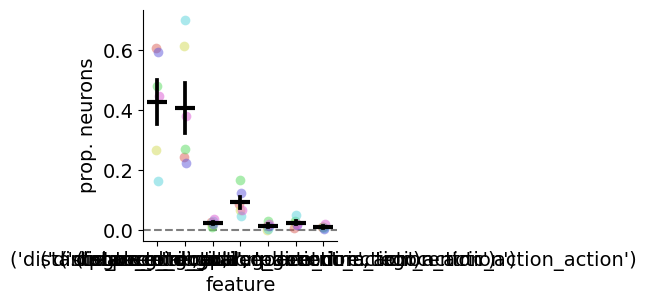

In [37]:
reload(ve)
f, ax = plt.subplots(figsize=(2.5, 3))
ve.plot_summary_pointplot(
    feature_tuned_df,
    models=compare_features,
    ax=ax,
)
f.savefig("../results/nbeGLM/figures/feature_tuning_summary.pdf")

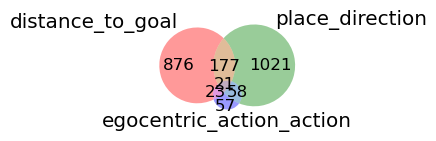

In [38]:
reload(ve)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ve.plot_summary_venn_diagram(
    feature_tuned_df,
    models=compare_features,
    ax=ax,
)
fig.savefig("../results/nbeGLM/figures/feature_tuning_venn.pdf")